In [1]:
!pip install numpy pandas scikit-learn matplotlib shap

Total readings per home: 5761
That's 60 days × 96 readings per day

CREATING DATA FOR 3 HOMES
Home A (Small): Average usage = 1.8 kWh  |  Total readings = 5761
Home B (Large): Average usage = 3.6 kWh  |  Total readings = 5761
Home C (Medium): Average usage = 2.7 kWh  |  Total readings = 5761

ADDING ANOMALIES (unusual spikes)
  → Added 20 anomalies (spikes of 10-15 kWh)
  → Added 20 anomalies (spikes of 10-15 kWh)
  → Added 20 anomalies (spikes of 10-15 kWh)

Features in CSV: ['timestamp', 'consumption_kwh', 'hour', 'is_weekend', 'is_anomaly']
That's it! Just: timestamp, consumption_kwh, hour, is_weekend, is_anomaly


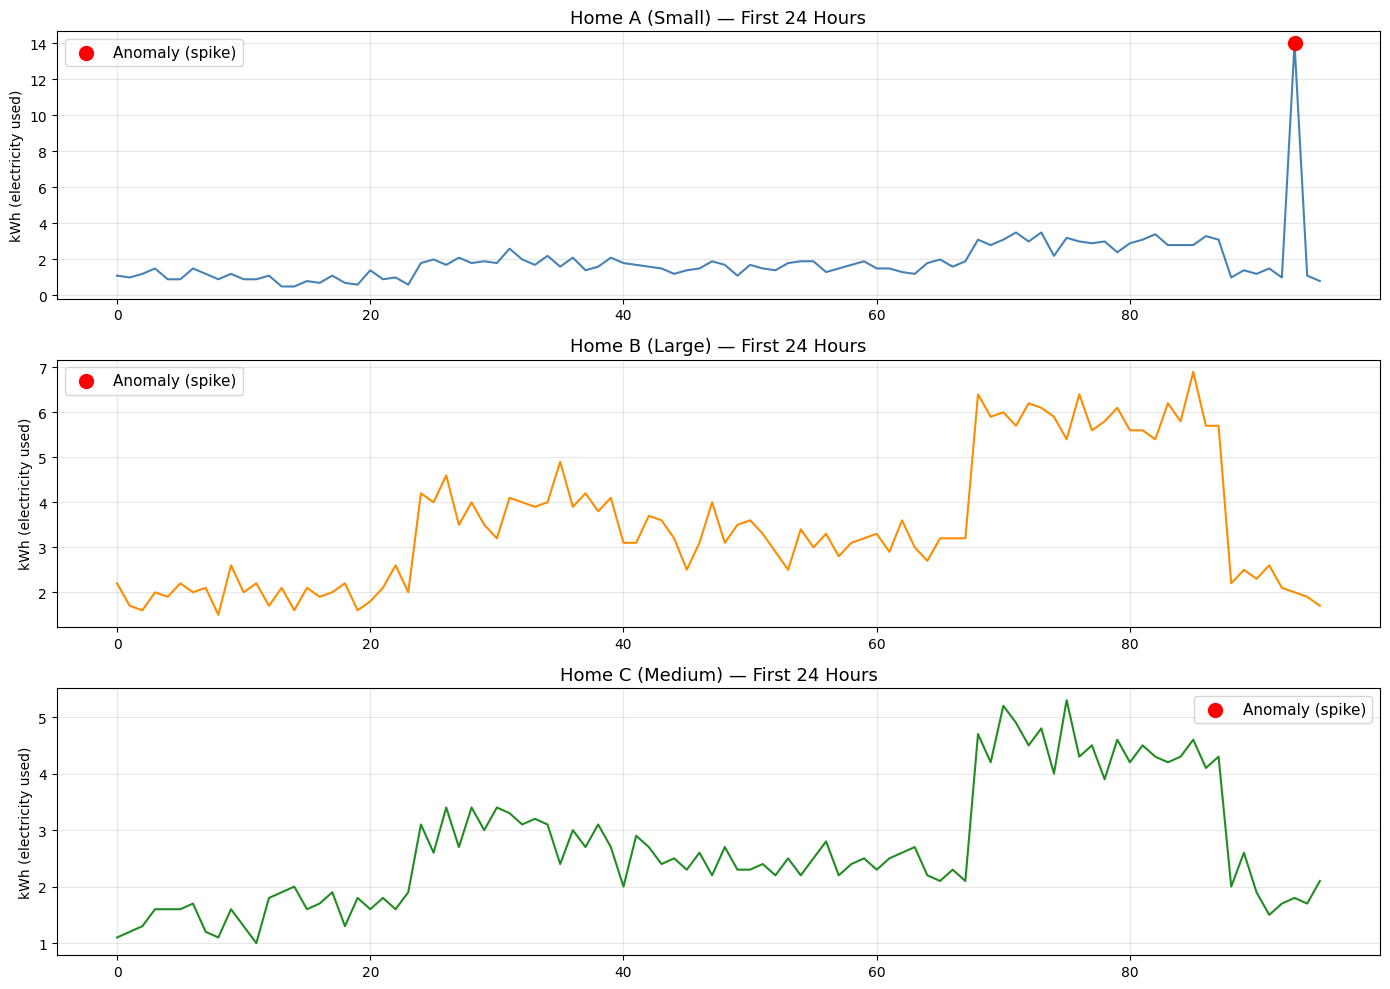


✅ Data created! Notice: anomalies are the tall red spikes.
   Normal usage is 1-6 kWh. Anomalies are 10-15 kWh.


In [2]:
# ══════════════════════════════════════════════
# STEP 1: CREATE SIMPLE DATA FOR 3 HOMES
# ══════════════════════════════════════════════
#
# Think of it like this:
#   - Home A = Small apartment  → uses 1-3 units of electricity
#   - Home B = Big family house → uses 3-6 units of electricity
#   - Home C = Medium house     → uses 2-4 units of electricity
#
# Each day has 96 readings (every 15 minutes).
# We create 60 days of data.
# ══════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)  # Same data every time you run

# Create timestamps: every 15 min for 60 days
timestamps = pd.date_range(start='2024-01-01', end='2024-03-01', freq='15min')
print(f"Total readings per home: {len(timestamps)}")
print(f"That's {len(timestamps) // 96} days × 96 readings per day\n")


def make_home_data(timestamps, base_usage, name):
    """
    Create simple electricity data for ONE home.

    base_usage = how much this home typically uses (in kWh)

    The pattern is simple:
      - Night (0-5 AM):   LOW usage  (everyone sleeping)
      - Morning (6-9 AM): MEDIUM     (waking up, breakfast)
      - Afternoon (10-4): MEDIUM     (some appliances)
      - Evening (5-10 PM): HIGH      (cooking, TV, lights)
      - Late night (11 PM): LOW      (going to sleep)
    """
    data = []
    for ts in timestamps:
        hour = ts.hour
        is_weekend = 1 if ts.dayofweek >= 5 else 0

        # Simple daily pattern
        if 0 <= hour <= 5:
            time_factor = 0.5    # Night: low
        elif 6 <= hour <= 9:
            time_factor = 1.0    # Morning: medium
        elif 10 <= hour <= 16:
            time_factor = 0.8    # Afternoon: medium-low
        elif 17 <= hour <= 21:
            time_factor = 1.5    # Evening: HIGH (peak)
        else:
            time_factor = 0.6    # Late night: low

        # Weekends: people stay home more → 10% more usage
        if is_weekend == 1:
            time_factor = time_factor * 1.1

        # Calculate consumption
        consumption = base_usage * time_factor + np.random.normal(0, 0.3)
        consumption = max(0.5, round(consumption, 1))  # Round to 1 decimal, min 0.5

        data.append({
            'timestamp': ts,
            'consumption_kwh': consumption,
            'hour': hour,
            'is_weekend': is_weekend,
        })

    df = pd.DataFrame(data)
    avg = df['consumption_kwh'].mean()
    print(f"{name}: Average usage = {avg:.1f} kWh  |  Total readings = {len(df)}")
    return df


# ── Create 3 homes ────────────────────────────
print("=" * 50)
print("CREATING DATA FOR 3 HOMES")
print("=" * 50)

df_a = make_home_data(timestamps, base_usage=2, name="Home A (Small)")
df_b = make_home_data(timestamps, base_usage=4, name="Home B (Large)")
df_c = make_home_data(timestamps, base_usage=3, name="Home C (Medium)")


# ── Add anomalies (unusual spikes) ───────────
# Normal usage: 1-6 kWh
# Anomaly: 10-15 kWh  (like leaving AC + oven + dryer on together!)
def add_anomalies(df, count=20):
    df = df.copy()
    df['is_anomaly'] = 0
    # Pick random positions (avoid first/last 10 rows)
    positions = np.random.choice(df.index[10:-10], size=count, replace=False)
    for pos in positions:
        df.at[pos, 'consumption_kwh'] = round(np.random.uniform(10, 15), 1)
        df.at[pos, 'is_anomaly'] = 1
    print(f"  → Added {count} anomalies (spikes of 10-15 kWh)")
    return df

print("\n" + "=" * 50)
print("ADDING ANOMALIES (unusual spikes)")
print("=" * 50)
df_a = add_anomalies(df_a)
df_b = add_anomalies(df_b)
df_c = add_anomalies(df_c)


# ── Save to CSV ───────────────────────────────
os.makedirs('homes', exist_ok=True)
df_a.to_csv('homes/home_a.csv', index=False)
df_b.to_csv('homes/home_b.csv', index=False)
df_c.to_csv('homes/home_c.csv', index=False)

print(f"\nFeatures in CSV: {list(df_a.columns)}")
print("That's it! Just: timestamp, consumption_kwh, hour, is_weekend, is_anomaly")


# ── Show the data visually ────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
colors = ['steelblue', 'darkorange', 'forestgreen']
names = ['Home A (Small)', 'Home B (Large)', 'Home C (Medium)']

for ax, df, color, name in zip(axes, [df_a, df_b, df_c], colors, names):
    sample = df.head(96)  # First 24 hours
    ax.plot(sample.index, sample['consumption_kwh'], color=color, lw=1.5)
    # Mark anomalies in red
    anomalies = sample[sample['is_anomaly'] == 1]
    ax.scatter(anomalies.index, anomalies['consumption_kwh'],
               color='red', s=100, zorder=5, label='Anomaly (spike)')
    ax.set_title(f'{name} — First 24 Hours', fontsize=13)
    ax.set_ylabel('kWh (electricity used)')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data_overview.png', dpi=150)
plt.show()

print("\n✅ Data created! Notice: anomalies are the tall red spikes.")
print("   Normal usage is 1-6 kWh. Anomalies are 10-15 kWh.")

STEP 2: PREDICTING ELECTRICITY USAGE
The model learns: 'At hour X, on weekday/weekend,
this home typically uses Y kWh of electricity.'

Training model for Home A
Loaded 5761 readings
  Learning from 4608 readings
  Testing on 1153 readings

  Average error: 0.3 kWh
  (Meaning: predictions are off by about 0.3 kWh on average)

  Example predictions:
    Hour= 0, Weekend → Actual: 1.3 kWh, Predicted: 1.1 kWh
    Hour= 9, Weekday → Actual: 2.4 kWh, Predicted: 2.1 kWh
    Hour=19, Weekday → Actual: 3.0 kWh, Predicted: 3.0 kWh
    Hour= 4, Weekend → Actual: 1.3 kWh, Predicted: 1.1 kWh
    Hour=14, Weekday → Actual: 1.5 kWh, Predicted: 1.6 kWh
    Hour=23, Weekday → Actual: 1.0 kWh, Predicted: 1.3 kWh


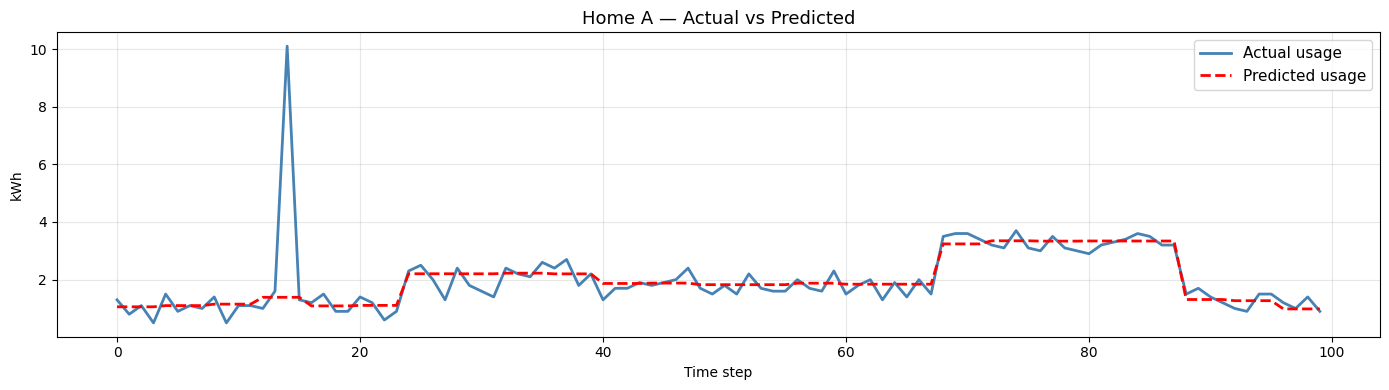


Training model for Home B
Loaded 5761 readings
  Learning from 4608 readings
  Testing on 1153 readings

  Average error: 0.3 kWh
  (Meaning: predictions are off by about 0.3 kWh on average)

  Example predictions:
    Hour= 0, Weekend → Actual: 2.7 kWh, Predicted: 2.3 kWh
    Hour= 9, Weekday → Actual: 4.1 kWh, Predicted: 4.1 kWh
    Hour=19, Weekday → Actual: 5.8 kWh, Predicted: 6.0 kWh
    Hour= 4, Weekend → Actual: 2.4 kWh, Predicted: 2.2 kWh
    Hour=14, Weekday → Actual: 3.8 kWh, Predicted: 3.2 kWh
    Hour=23, Weekday → Actual: 2.3 kWh, Predicted: 2.4 kWh


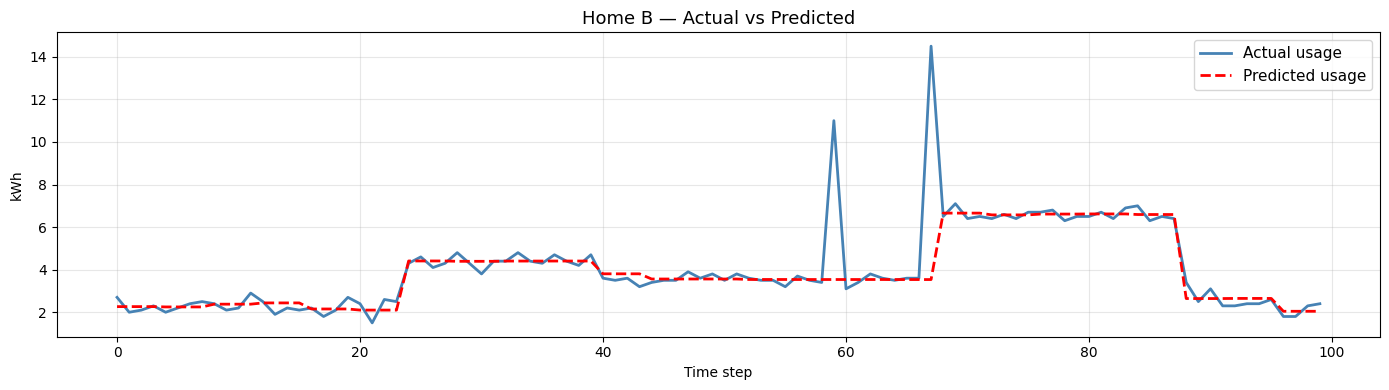


Training model for Home C
Loaded 5761 readings
  Learning from 4608 readings
  Testing on 1153 readings

  Average error: 0.3 kWh
  (Meaning: predictions are off by about 0.3 kWh on average)

  Example predictions:
    Hour= 0, Weekend → Actual: 1.7 kWh, Predicted: 1.7 kWh
    Hour= 9, Weekday → Actual: 2.7 kWh, Predicted: 3.1 kWh
    Hour=19, Weekday → Actual: 4.1 kWh, Predicted: 4.5 kWh
    Hour= 4, Weekend → Actual: 1.3 kWh, Predicted: 1.7 kWh
    Hour=14, Weekday → Actual: 2.2 kWh, Predicted: 2.4 kWh
    Hour=23, Weekday → Actual: 1.9 kWh, Predicted: 1.9 kWh


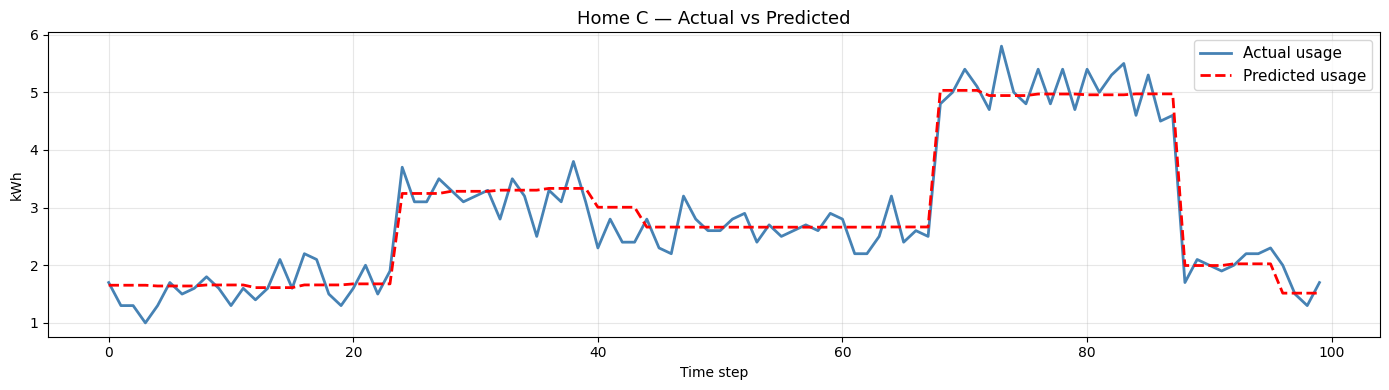


SUMMARY
  Home A: Average prediction error = 0.3 kWh
  Home B: Average prediction error = 0.3 kWh
  Home C: Average prediction error = 0.3 kWh

✅ Forecasting done! The model learned each home's daily pattern.


In [3]:
# ══════════════════════════════════════════════
# STEP 2: PREDICT ELECTRICITY USAGE
# ══════════════════════════════════════════════
#
# We teach a model:
#   "Given the HOUR and whether it's WEEKEND,
#    predict how much electricity will be used."
#
# That's it. Just 2 inputs → 1 output.
#
#   hour=19, is_weekend=0  →  predicts 5 kWh
#   hour=3,  is_weekend=1  →  predicts 1 kWh
# ══════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import pickle, os

os.makedirs('models', exist_ok=True)

# Only 2 features. Simple.
FEATURES = ['hour', 'is_weekend']
TARGET = 'consumption_kwh'


def train_and_test(home_name, file_path):
    print(f"\n{'='*50}")
    print(f"Training model for {home_name}")
    print('='*50)

    df = pd.read_csv(file_path)
    print(f"Loaded {len(df)} readings")

    X = df[FEATURES].values   # Inputs: hour, is_weekend
    y = df[TARGET].values     # Output: consumption

    # Split: first 80% for learning, last 20% for testing
    split = int(len(df) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    print(f"  Learning from {len(X_train)} readings")
    print(f"  Testing on {len(X_test)} readings")

    # Train the model
    model = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
    model.fit(X_train, y_train)

    # Test it
    predictions = model.predict(X_test)
    error = mean_absolute_error(y_test, predictions)
    print(f"\n  Average error: {error:.1f} kWh")
    print(f"  (Meaning: predictions are off by about {error:.1f} kWh on average)")

    # Show some example predictions
    print(f"\n  Example predictions:")
    for i in range(0, len(X_test), len(X_test)//5):
        h, w = X_test[i]
        actual = y_test[i]
        pred = predictions[i]
        weekend_str = "Weekend" if w == 1 else "Weekday"
        print(f"    Hour={int(h):2d}, {weekend_str:7s} → Actual: {actual:.1f} kWh, Predicted: {pred:.1f} kWh")

    # Save model
    model_file = f'models/model_{home_name[-1].lower()}.pkl'
    with open(model_file, 'wb') as f:
        pickle.dump(model, f)

    # Plot actual vs predicted
    fig, ax = plt.subplots(figsize=(14, 4))
    n = 100
    ax.plot(y_test[:n], label='Actual usage', color='steelblue', lw=2)
    ax.plot(predictions[:n], label='Predicted usage', color='red', lw=2, linestyle='--')
    ax.set_title(f'{home_name} — Actual vs Predicted', fontsize=13)
    ax.set_xlabel('Time step')
    ax.set_ylabel('kWh')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'forecast_{home_name.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

    return model, error


# Train all 3 homes
print("=" * 50)
print("STEP 2: PREDICTING ELECTRICITY USAGE")
print("=" * 50)
print("The model learns: 'At hour X, on weekday/weekend,")
print("this home typically uses Y kWh of electricity.'")

models = {}
errors = {}
for name, path in [('Home A', 'homes/home_a.csv'),
                    ('Home B', 'homes/home_b.csv'),
                    ('Home C', 'homes/home_c.csv')]:
    m, e = train_and_test(name, path)
    models[name] = m
    errors[name] = e

print(f"\n{'='*50}")
print("SUMMARY")
print(f"{'='*50}")
for name, e in errors.items():
    print(f"  {name}: Average prediction error = {e:.1f} kWh")

print("\n✅ Forecasting done! The model learned each home's daily pattern.")

STEP 3: ANOMALY DETECTION
Like a security guard watching for unusual electricity usage.

Checking Home A for unusual usage...

  Real anomalies we created:     20
  Anomalies the guard detected:  58
  Real anomalies caught:         20
  Real anomalies missed:         0
  False alarms (normal flagged): 38

  Examples of DETECTED anomalies:
    Hour 23: 14.0 kWh  ← unusual!
    Hour  5: 12.9 kWh  ← unusual!
    Hour 23: 0.6 kWh  ← unusual!
    Hour 23: 0.6 kWh  ← unusual!
    Hour 23: 0.5 kWh  ← unusual!


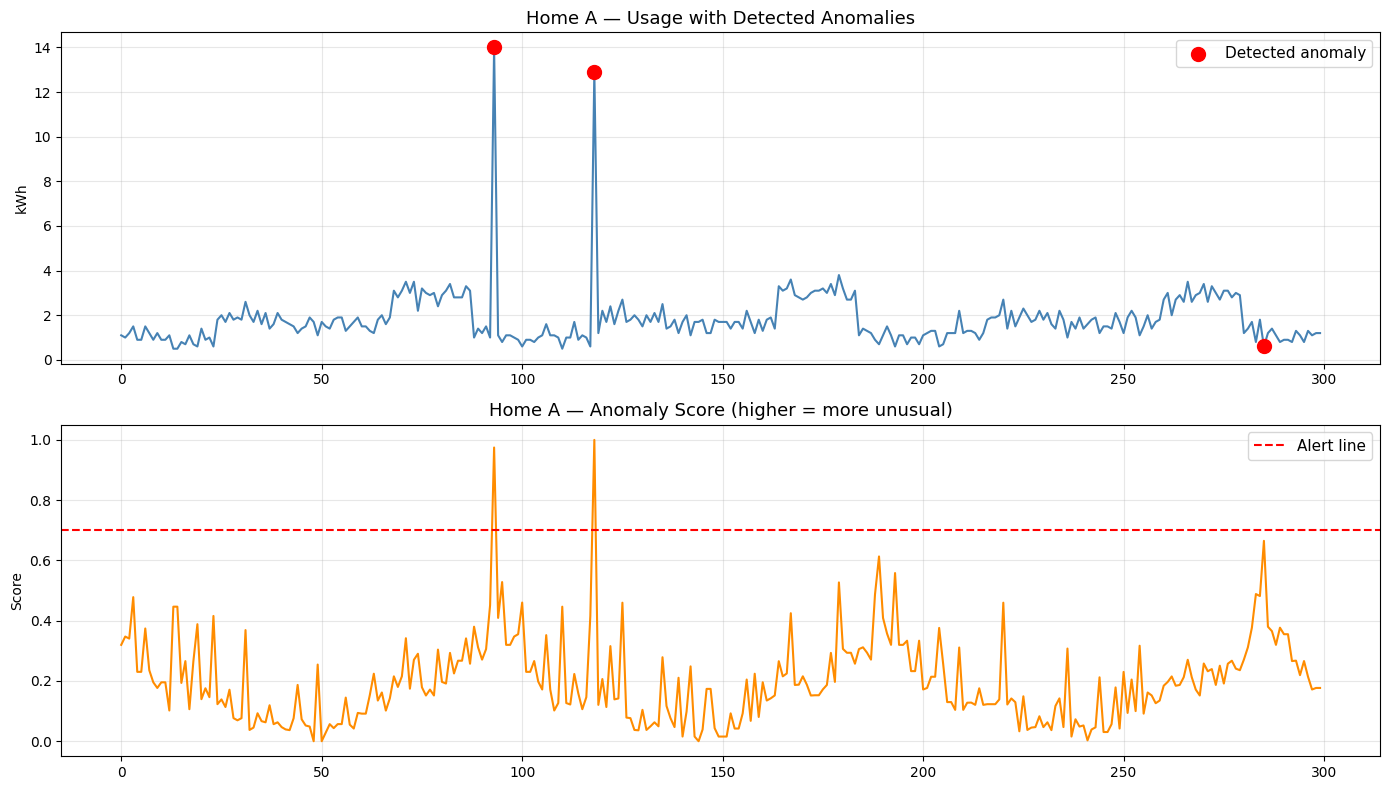


Checking Home B for unusual usage...

  Real anomalies we created:     20
  Anomalies the guard detected:  58
  Real anomalies caught:         20
  Real anomalies missed:         0
  False alarms (normal flagged): 38

  Examples of DETECTED anomalies:
    Hour 23: 1.7 kWh  ← unusual!
    Hour  9: 13.1 kWh  ← unusual!
    Hour 22: 1.7 kWh  ← unusual!
    Hour 18: 7.3 kWh  ← unusual!
    Hour 21: 7.0 kWh  ← unusual!


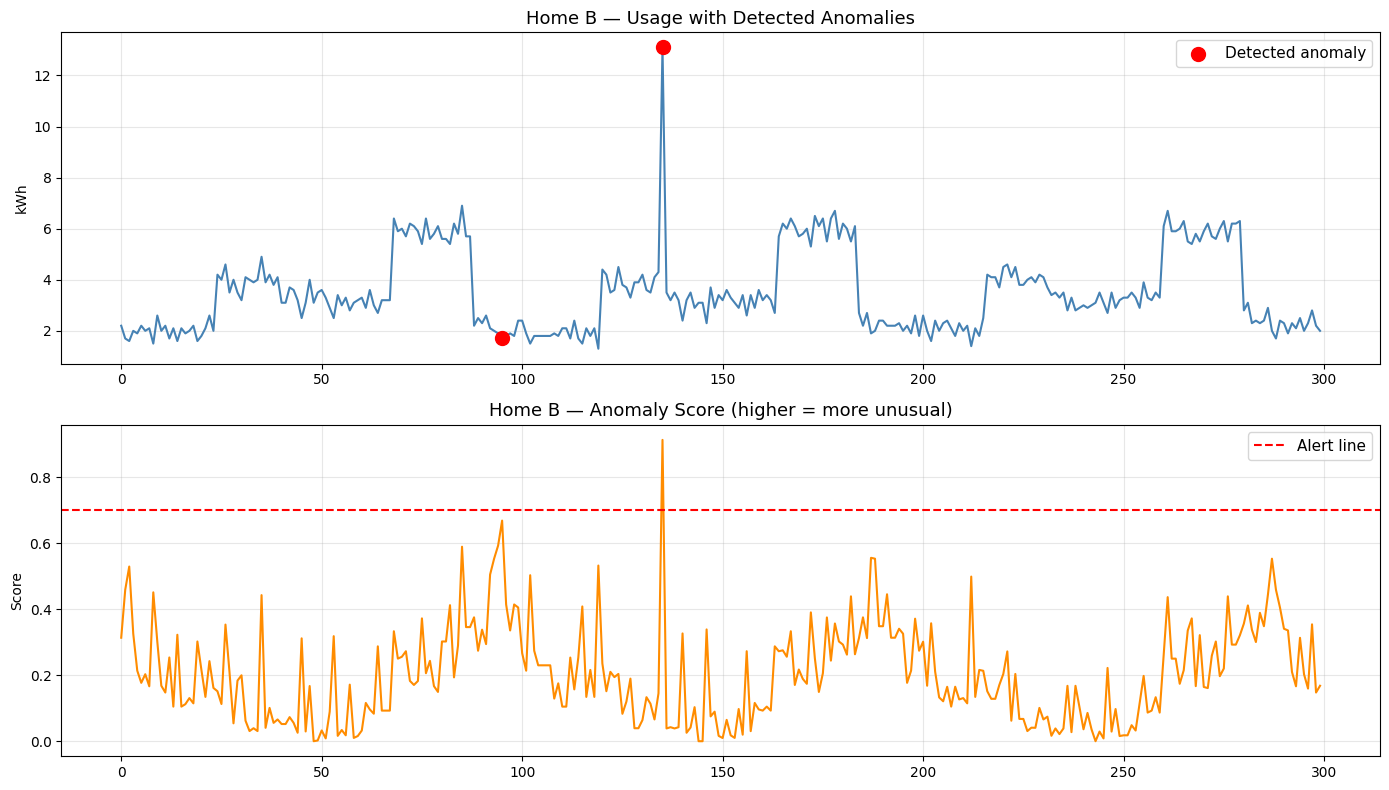


Checking Home C for unusual usage...

  Real anomalies we created:     20
  Anomalies the guard detected:  58
  Real anomalies caught:         20
  Real anomalies missed:         0
  False alarms (normal flagged): 38

  Examples of DETECTED anomalies:
    Hour 17: 11.5 kWh  ← unusual!
    Hour  7: 13.1 kWh  ← unusual!
    Hour 23: 1.1 kWh  ← unusual!
    Hour 23: 1.2 kWh  ← unusual!
    Hour 18: 5.7 kWh  ← unusual!


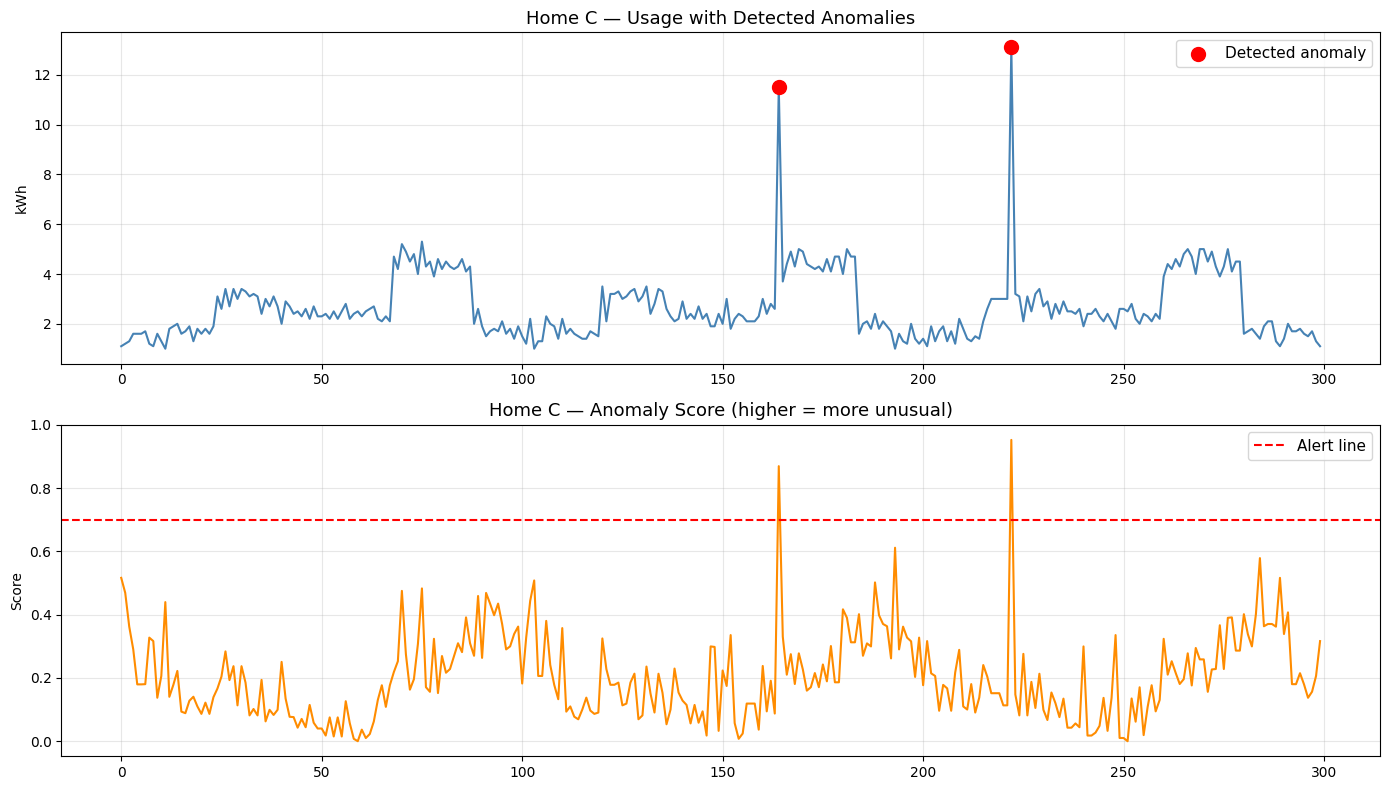


✅ Anomaly detection done!


In [4]:
# ══════════════════════════════════════════════
# STEP 3: DETECT UNUSUAL USAGE (ANOMALIES)
# ══════════════════════════════════════════════
#
# Think of it like a security guard watching electricity usage.
#
# Normal: Home uses 1-6 kWh   → Guard says "All normal"
# Weird:  Home uses 12 kWh    → Guard says "WAIT, that's unusual!"
#
# We use "Isolation Forest" — it learns what "normal" looks like
# and flags anything that doesn't fit.
# ══════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest


def find_anomalies(home_name, file_path):
    print(f"\n{'='*50}")
    print(f"Checking {home_name} for unusual usage...")
    print('='*50)

    df = pd.read_csv(file_path)

    # We only look at 2 things: how much electricity + what hour
    X = df[['consumption_kwh', 'hour']].values
    actual_anomalies = df['is_anomaly'].values  # The real answer

    # Train the "security guard"
    # contamination=0.01 means "about 1% of readings might be unusual"
    guard = IsolationForest(contamination=0.01, n_estimators=100, random_state=42)
    guard.fit(X)

    # Ask the guard to check every reading
    raw_result = guard.predict(X)
    # raw_result: -1 means "unusual", 1 means "normal"
    # Convert: 1 = anomaly, 0 = normal
    detected = (raw_result == -1).astype(int)

    # Get anomaly scores (0 = normal, closer to 1 = more unusual)
    scores = guard.score_samples(X)
    scores_01 = 1 - ((scores - scores.min()) / (scores.max() - scores.min()))

    # Count results
    total_anomalies = actual_anomalies.sum()
    total_detected = detected.sum()
    caught = ((detected == 1) & (actual_anomalies == 1)).sum()
    missed = ((detected == 0) & (actual_anomalies == 1)).sum()
    false_alarm = ((detected == 1) & (actual_anomalies == 0)).sum()

    print(f"\n  Real anomalies we created:     {total_anomalies}")
    print(f"  Anomalies the guard detected:  {total_detected}")
    print(f"  Real anomalies caught:         {caught}")
    print(f"  Real anomalies missed:         {missed}")
    print(f"  False alarms (normal flagged): {false_alarm}")

    # Show some examples
    print(f"\n  Examples of DETECTED anomalies:")
    anomaly_rows = df[detected == 1].head(5)
    for _, row in anomaly_rows.iterrows():
        print(f"    Hour {int(row['hour']):2d}: {row['consumption_kwh']:.1f} kWh  ← unusual!")

    # Plot
    df['detected'] = detected
    df['score'] = scores_01

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    sample = df.head(300)

    ax1.plot(sample.index, sample['consumption_kwh'], color='steelblue', lw=1.5)
    flagged = sample[sample['detected'] == 1]
    ax1.scatter(flagged.index, flagged['consumption_kwh'],
                color='red', s=100, zorder=5, label='Detected anomaly')
    ax1.set_title(f'{home_name} — Usage with Detected Anomalies', fontsize=13)
    ax1.set_ylabel('kWh')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    ax2.plot(sample.index, sample['score'], color='darkorange', lw=1.5)
    ax2.axhline(y=0.7, color='red', linestyle='--', label='Alert line')
    ax2.set_title(f'{home_name} — Anomaly Score (higher = more unusual)', fontsize=13)
    ax2.set_ylabel('Score')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'anomaly_{home_name.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

    return caught, missed, false_alarm


print("=" * 50)
print("STEP 3: ANOMALY DETECTION")
print("=" * 50)
print("Like a security guard watching for unusual electricity usage.")

for name, path in [('Home A', 'homes/home_a.csv'),
                    ('Home B', 'homes/home_b.csv'),
                    ('Home C', 'homes/home_c.csv')]:
    find_anomalies(name, path)

print("\n✅ Anomaly detection done!")

STEP 4: LOCAL vs CENTRALIZED LEARNING

--- LOCAL: Each home learns by itself ---
  Home A alone → error: 0.3 kWh
  Home B alone → error: 0.3 kWh
  Home C alone → error: 0.3 kWh

--- CENTRALIZED: All homes combined ---
  Home A (shared model) → error: 1.0 kWh
  Home B (shared model) → error: 0.9 kWh
  Home C (shared model) → error: 0.3 kWh

COMPARISON (lower error = better)
Home            Alone   Together
--------------------------------
Home A            0.3        1.0
Home B            0.3        0.9
Home C            0.3        0.3


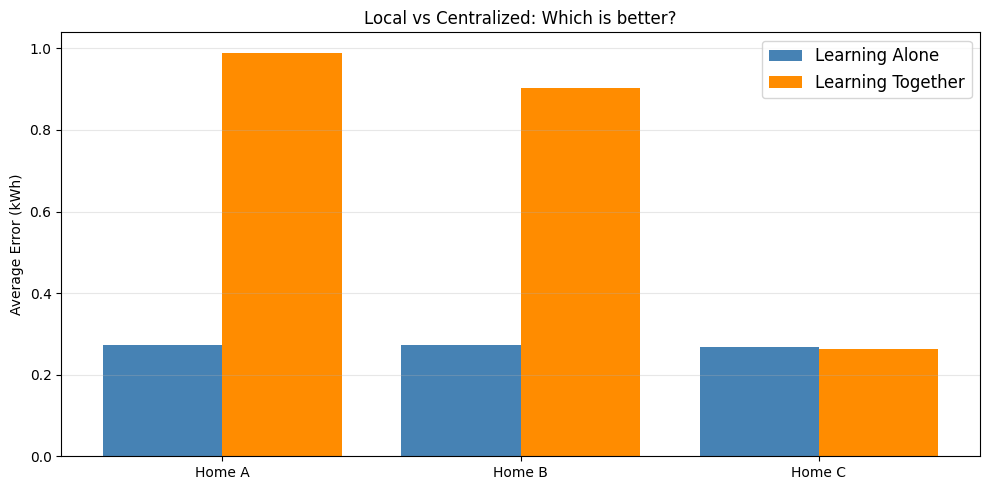


✅ Comparison done!


In [5]:
# ══════════════════════════════════════════════
# STEP 4: LOCAL vs CENTRALIZED
# ══════════════════════════════════════════════
#
# Question: Is it better for each home to learn ALONE,
#           or for all homes to learn TOGETHER?
#
# LOCAL:       Each home trains its own model
# CENTRALIZED: All data combined into one big model
# ══════════════════════════════════════════════

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

FEATURES = ['hour', 'is_weekend']
TARGET = 'consumption_kwh'

def load_data(path):
    df = pd.read_csv(path)
    X = df[FEATURES].values
    y = df[TARGET].values
    split = int(len(X) * 0.8)
    return X[:split], X[split:], y[:split], y[split:]

print("=" * 50)
print("STEP 4: LOCAL vs CENTRALIZED LEARNING")
print("=" * 50)

# Load all homes
Xa_tr, Xa_te, ya_tr, ya_te = load_data('homes/home_a.csv')
Xb_tr, Xb_te, yb_tr, yb_te = load_data('homes/home_b.csv')
Xc_tr, Xc_te, yc_tr, yc_te = load_data('homes/home_c.csv')

# ── LOCAL: Each home learns alone ─────────────
print("\n--- LOCAL: Each home learns by itself ---")
local_errors = {}
for name, Xtr, Xte, ytr, yte in [('Home A', Xa_tr, Xa_te, ya_tr, ya_te),
                                   ('Home B', Xb_tr, Xb_te, yb_tr, yb_te),
                                   ('Home C', Xc_tr, Xc_te, yc_tr, yc_te)]:
    m = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
    m.fit(Xtr, ytr)
    err = mean_absolute_error(yte, m.predict(Xte))
    local_errors[name] = err
    print(f"  {name} alone → error: {err:.1f} kWh")

# ── CENTRALIZED: All homes learn together ─────
print("\n--- CENTRALIZED: All homes combined ---")
X_all = np.vstack([Xa_tr, Xb_tr, Xc_tr])
y_all = np.concatenate([ya_tr, yb_tr, yc_tr])
central_model = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
central_model.fit(X_all, y_all)

central_errors = {}
for name, Xte, yte in [('Home A', Xa_te, ya_te),
                         ('Home B', Xb_te, yb_te),
                         ('Home C', Xc_te, yc_te)]:
    err = mean_absolute_error(yte, central_model.predict(Xte))
    central_errors[name] = err
    print(f"  {name} (shared model) → error: {err:.1f} kWh")

# ── Compare ───────────────────────────────────
print(f"\n{'='*50}")
print("COMPARISON (lower error = better)")
print(f"{'='*50}")
print(f"{'Home':<10} {'Alone':>10} {'Together':>10}")
print("-" * 32)
for name in ['Home A', 'Home B', 'Home C']:
    print(f"{name:<10} {local_errors[name]:>10.1f} {central_errors[name]:>10.1f}")

# Plot comparison
homes = ['Home A', 'Home B', 'Home C']
x = np.arange(len(homes))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, [local_errors[h] for h in homes], 0.4, label='Learning Alone', color='steelblue')
ax.bar(x + 0.2, [central_errors[h] for h in homes], 0.4, label='Learning Together', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(homes)
ax.set_ylabel('Average Error (kWh)')
ax.set_title('Local vs Centralized: Which is better?')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('local_vs_central.png', dpi=150)
plt.show()

print("\n✅ Comparison done!")

STEP 5: FEDERATED LEARNING
Each home learns locally. Then they share 'hints'.
No raw data leaves the home — only lessons.

--- Round 1/5 ---
  Home A: error = 0.3 kWh
  Home B: error = 0.3 kWh
  Home C: error = 0.3 kWh

--- Round 2/5 ---
  Home A: error = 0.4 kWh
  Home B: error = 0.4 kWh
  Home C: error = 0.3 kWh

--- Round 3/5 ---
  Home A: error = 0.4 kWh
  Home B: error = 0.4 kWh
  Home C: error = 0.3 kWh

--- Round 4/5 ---
  Home A: error = 0.4 kWh
  Home B: error = 0.4 kWh
  Home C: error = 0.3 kWh

--- Round 5/5 ---
  Home A: error = 0.4 kWh
  Home B: error = 0.4 kWh
  Home C: error = 0.3 kWh



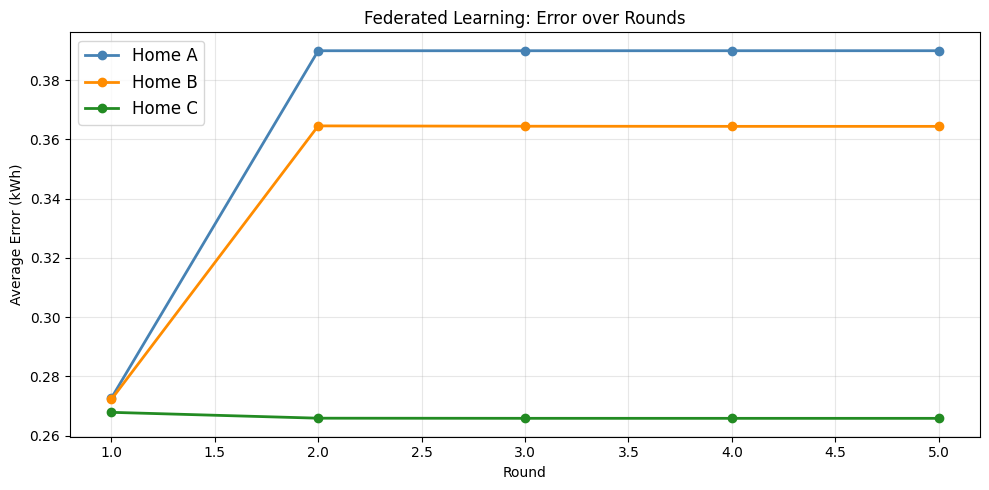

✅ Federated Learning done!
Each round, homes share 'lessons' without sharing raw data.


In [6]:
# ══════════════════════════════════════════════
# STEP 5: FEDERATED LEARNING (Simplified)
# ══════════════════════════════════════════════
#
# Real Federated Learning: Homes learn locally and
# ONLY share "lessons learned", NOT raw data.
#
# Here we simulate it simply:
#   Round 1: Each home learns alone
#   Round 2+: Each home gets a "hint" from the group
#
# Think of it like 3 students studying:
#   - Round 1: Each studies alone
#   - Round 2: They share notes, then study again
# ══════════════════════════════════════════════

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

FEATURES = ['hour', 'is_weekend']
TARGET = 'consumption_kwh'

def load(path):
    df = pd.read_csv(path)
    X = df[FEATURES].values
    y = df[TARGET].values
    s = int(len(X) * 0.8)
    return X[:s], X[s:], y[:s], y[s:]

Xa_tr, Xa_te, ya_tr, ya_te = load('homes/home_a.csv')
Xb_tr, Xb_te, yb_tr, yb_te = load('homes/home_b.csv')
Xc_tr, Xc_te, yc_tr, yc_te = load('homes/home_c.csv')

print("=" * 50)
print("STEP 5: FEDERATED LEARNING")
print("=" * 50)
print("Each home learns locally. Then they share 'hints'.")
print("No raw data leaves the home — only lessons.\n")

N_ROUNDS = 5
history = {'Home A': [], 'Home B': [], 'Home C': []}
global_model = None

for round_num in range(1, N_ROUNDS + 1):
    print(f"--- Round {round_num}/{N_ROUNDS} ---")

    # Each home trains locally
    local_models = {}
    for name, Xtr, ytr in [('Home A', Xa_tr, ya_tr),
                            ('Home B', Xb_tr, yb_tr),
                            ('Home C', Xc_tr, yc_tr)]:
        m = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)

        if global_model is not None and round_num > 1:
            # Mix: 70% own knowledge + 30% group hint
            hint = global_model.predict(Xtr)
            y_mixed = 0.7 * ytr + 0.3 * hint
        else:
            y_mixed = ytr

        m.fit(Xtr, y_mixed)
        local_models[name] = m

    # Evaluate each home's model
    for name, model, Xte, yte in [('Home A', local_models['Home A'], Xa_te, ya_te),
                                    ('Home B', local_models['Home B'], Xb_te, yb_te),
                                    ('Home C', local_models['Home C'], Xc_te, yc_te)]:
        err = mean_absolute_error(yte, model.predict(Xte))
        history[name].append(err)
        print(f"  {name}: error = {err:.1f} kWh")

    # Combine: average predictions from all homes
    # (This is the "sharing hints" part)
    sample_X = Xa_tr[:200]
    all_preds = np.array([m.predict(sample_X) for m in local_models.values()])
    avg_pred = all_preds.mean(axis=0)
    global_model = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
    global_model.fit(sample_X, avg_pred)
    print()

# Plot learning over rounds
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'Home A': 'steelblue', 'Home B': 'darkorange', 'Home C': 'forestgreen'}
for name in ['Home A', 'Home B', 'Home C']:
    ax.plot(range(1, N_ROUNDS+1), history[name], marker='o', label=name, color=colors[name], lw=2)
ax.set_xlabel('Round')
ax.set_ylabel('Average Error (kWh)')
ax.set_title('Federated Learning: Error over Rounds')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('federated_learning.png', dpi=150)
plt.show()

print("✅ Federated Learning done!")
print("Each round, homes share 'lessons' without sharing raw data.")

In [7]:
# ══════════════════════════════════════════════
# STEP 6: SHAP — WHY DID THE MODEL PREDICT THAT?
# ══════════════════════════════════════════════
#
# The model says "5 kWh" but WHY?
# SHAP answers: "Because it's 7 PM (evening peak)
#                and it's a weekend."
#
# With only 2 features, this is super easy to see.
# ══════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle

FEATURES = ['hour', 'is_weekend']

print("=" * 50)
print("STEP 6: EXPLAINING PREDICTIONS WITH SHAP")
print("=" * 50)

for name in ['Home A', 'Home B', 'Home C']:
    print(f"\n{'='*50}")
    print(f"Explaining {name}")
    print('='*50)

    with open(f'models/model_{name[-1].lower()}.pkl', 'rb') as f:
        model = pickle.load(f)
    df = pd.read_csv(f'homes/home_{name[-1].lower()}.csv')
    X = df[FEATURES].values[:200]

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    # Average importance
    mean_importance = np.abs(shap_values).mean(axis=0)
    print(f"\n  Feature importance (SHAP):")
    for feat, imp in zip(FEATURES, mean_importance):
        bar = '█' * int(imp / max(mean_importance) * 30)
        print(f"    {feat:12s} {bar} {imp:.2f}")

    # Explain ONE prediction
    idx = 50
    pred = model.predict(X[idx:idx+1])[0]
    base = explainer.expected_value
    if isinstance(base, np.ndarray):
        base = base.item()

    print(f"\n  Example explanation:")
    print(f"    Base (average prediction): {base:.1f} kWh")
    for feat, sv in zip(FEATURES, shap_values[idx]):
        direction = "increases" if sv > 0 else "decreases"
        print(f"    {feat} {direction} prediction by {abs(sv):.1f} kWh")
    print(f"    Final prediction: {pred:.1f} kWh")

print("\n✅ SHAP done! Now you know WHY the model predicts what it does.")

STEP 6: EXPLAINING PREDICTIONS WITH SHAP

Explaining Home A

  Feature importance (SHAP):
    hour         ██████████████████████████████ 0.58
    is_weekend   ██ 0.05

  Example explanation:
    Base (average prediction): 1.9 kWh
    hour decreases prediction by 0.1 kWh
    is_weekend decreases prediction by 0.0 kWh
    Final prediction: 1.7 kWh

Explaining Home B

  Feature importance (SHAP):
    hour         ██████████████████████████████ 1.21
    is_weekend   ██ 0.10

  Example explanation:
    Base (average prediction): 3.7 kWh
    hour decreases prediction by 0.4 kWh
    is_weekend decreases prediction by 0.1 kWh
    Final prediction: 3.2 kWh

Explaining Home C

  Feature importance (SHAP):
    hour         ██████████████████████████████ 0.90
    is_weekend   ██ 0.07

  Example explanation:
    Base (average prediction): 2.8 kWh
    hour decreases prediction by 0.3 kWh
    is_weekend decreases prediction by 0.1 kWh
    Final prediction: 2.4 kWh

✅ SHAP done! Now you know WHY the 

In [8]:
# ══════════════════════════════════════════════
# STEP 7: ENERGY AGENT
# ══════════════════════════════════════════════
#
# Think of this as a SMART ALARM SYSTEM for your home.
#
# It does 3 things:
#   1. OBSERVE: "What's happening right now?"
#   2. REASON:  "Is this normal or dangerous?"
#   3. ACT:     "What should we do about it?"
#
# Just like a smoke detector:
#   - No smoke     → "All clear"
#   - Lots of smoke → "FIRE ALARM!"
#
# Our agent checks:
#   - Is the anomaly score high?  (like smoke level)
#   - Is the predicted usage high? (like heat level)
#
# If BOTH are high → CRITICAL
# If ONE is high  → WARNING
# If NEITHER      → NORMAL
# ══════════════════════════════════════════════

import pickle
import pandas as pd
import numpy as np

FEATURES = ['hour', 'is_weekend']


class EnergyAgent:
    """A simple alarm system for home electricity usage."""

    def __init__(self, home_name, model_path):
        self.home_name = home_name
        with open(model_path, 'rb') as f:
            self.model = pickle.load(f)

        # Simple thresholds (easy to understand)
        self.HIGH_USAGE = 5       # Above 5 kWh = high
        self.VERY_HIGH_USAGE = 8  # Above 8 kWh = very high
        self.ANOMALY_ALERT = 0.5  # Above 0.5 = suspicious
        self.ANOMALY_DANGER = 0.7 # Above 0.7 = dangerous

        print(f"  Agent created for {home_name}")

    def check(self, hour, is_weekend, anomaly_score):
        """
        The agent checks the situation and gives a verdict.

        Inputs:
          hour          → What time is it? (0-23)
          is_weekend    → Is it weekend? (0 or 1)
          anomaly_score → How unusual is this? (0 to 1)

        Output:
          A simple verdict: NORMAL, WARNING, or CRITICAL
        """
        # Step 1: OBSERVE — What does the model predict?
        features = np.array([[hour, is_weekend]])
        predicted_usage = self.model.predict(features)[0]

        # Step 2: REASON — Is this normal?
        problems = []

        if anomaly_score > self.ANOMALY_DANGER:
            problems.append(f"Anomaly score is VERY HIGH ({anomaly_score:.1f})")
        elif anomaly_score > self.ANOMALY_ALERT:
            problems.append(f"Anomaly score is HIGH ({anomaly_score:.1f})")

        if predicted_usage > self.VERY_HIGH_USAGE:
            problems.append(f"Predicted usage is VERY HIGH ({predicted_usage:.1f} kWh)")
        elif predicted_usage > self.HIGH_USAGE:
            problems.append(f"Predicted usage is HIGH ({predicted_usage:.1f} kWh)")

        # Step 3: ACT — What should we do?
        if len(problems) >= 2:
            verdict = "CRITICAL"
            action = "IMMEDIATE CHECK NEEDED!"
        elif len(problems) == 1:
            verdict = "WARNING"
            action = "Keep watching closely."
        else:
            verdict = "NORMAL"
            action = "All good. No action needed."

        return {
            'home': self.home_name,
            'hour': hour,
            'predicted_kwh': round(predicted_usage, 1),
            'anomaly_score': round(anomaly_score, 2),
            'problems_found': problems,
            'verdict': verdict,
            'action': action,
        }


# ══════════════════════════════════════════════
# DEMO: Show the agent in action
# ══════════════════════════════════════════════

print("=" * 55)
print("  ENERGY AGENT — Like a Smart Alarm for Your Home")
print("=" * 55)
print()
print("How it works:")
print("  1. OBSERVE → Check predicted usage + anomaly score")
print("  2. REASON  → Is this normal or dangerous?")
print("  3. ACT     → Tell the homeowner what to do")
print()

agent = EnergyAgent('Home A', 'models/model_a.pkl')

# ── Test 1: Normal evening ────────────────────
print("─" * 55)
print("TEST 1: Normal evening usage")
print("  → It's 7 PM on a weekday")
print("  → Anomaly score is LOW (0.2)")
print("  → Expected: Everything is fine")
print("─" * 55)

result = agent.check(hour=19, is_weekend=0, anomaly_score=0.2)
print(f"  Predicted usage:  {result['predicted_kwh']} kWh")
print(f"  Anomaly score:    {result['anomaly_score']}")
print(f"  Problems found:   {result['problems_found'] if result['problems_found'] else 'None'}")
print(f"  ➤ Verdict:        {result['verdict']}")
print(f"  ➤ Action:         {result['action']}")

# ── Test 2: Something is wrong! ───────────────
print()
print("─" * 55)
print("TEST 2: Something is VERY WRONG")
print("  → It's 3 AM (should be low usage)")
print("  → Anomaly score is VERY HIGH (0.9)")
print("  → Expected: ALARM!")
print("─" * 55)

result = agent.check(hour=3, is_weekend=0, anomaly_score=0.9)
print(f"  Predicted usage:  {result['predicted_kwh']} kWh")
print(f"  Anomaly score:    {result['anomaly_score']}")
print(f"  Problems found:   {result['problems_found']}")
print(f"  ➤ Verdict:        {result['verdict']}")
print(f"  ➤ Action:         {result['action']}")

# ── Test 3: Slightly suspicious ───────────────
print()
print("─" * 55)
print("TEST 3: Slightly suspicious")
print("  → It's 8 PM on a weekend")
print("  → Anomaly score is MEDIUM (0.6)")
print("  → Expected: WARNING")
print("─" * 55)

result = agent.check(hour=20, is_weekend=1, anomaly_score=0.6)
print(f"  Predicted usage:  {result['predicted_kwh']} kWh")
print(f"  Anomaly score:    {result['anomaly_score']}")
print(f"  Problems found:   {result['problems_found']}")
print(f"  ➤ Verdict:        {result['verdict']}")
print(f"  ➤ Action:         {result['action']}")

print()
print("=" * 55)
print("✅ Agent demo complete!")
print()
print("Summary:")
print("  NORMAL   = All good, relax")
print("  WARNING  = Something's a bit off, keep watching")
print("  CRITICAL = DANGER! Check immediately!")
print("=" * 55)

  ENERGY AGENT — Like a Smart Alarm for Your Home

How it works:
  1. OBSERVE → Check predicted usage + anomaly score
  2. REASON  → Is this normal or dangerous?
  3. ACT     → Tell the homeowner what to do

  Agent created for Home A
───────────────────────────────────────────────────────
TEST 1: Normal evening usage
  → It's 7 PM on a weekday
  → Anomaly score is LOW (0.2)
  → Expected: Everything is fine
───────────────────────────────────────────────────────
  Predicted usage:  3.0 kWh
  Anomaly score:    0.2
  Problems found:   None
  ➤ Verdict:        NORMAL
  ➤ Action:         All good. No action needed.

───────────────────────────────────────────────────────
TEST 2: Something is VERY WRONG
  → It's 3 AM (should be low usage)
  → Anomaly score is VERY HIGH (0.9)
  → Expected: ALARM!
───────────────────────────────────────────────────────
  Predicted usage:  1.2 kWh
  Anomaly score:    0.9
  Problems found:   ['Anomaly score is VERY HIGH (0.9)']
  ➤ Verdict:        WARNING
  ➤ A